## End to end Project
### Data Science 8CC2
### Universidad Autónoma de Chihuahua
### Facultad de Ingenieria
### Ingenieria en ciencias de la computación
### Docente: Olanda Prieto Ordaz
### Fecha de entrega: Jueves 4 de septiembre del 2025
*Allan Hall Solorio 358909*

In [1]:
# 1º Obtener los datos
import os # Importa el módulo os para interactuar con el sistema operativo
import tarfile # Importa el módulo tarfile para trabajar con archivos tar
import urllib # Importa el módulo urllib para obtener datos de URLs

# Define la URL raíz para descargar el conjunto de datos
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
# Define la ruta donde se almacenará el conjunto de datos
HOUSING_PATH = os.path.join("datasets", "housing")
# Define la URL completa del archivo tar del conjunto de datos de viviendas
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

# Define una función para obtener los datos de viviendas
def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    # Crea el directorio para almacenar el conjunto de datos si no existe
    os.makedirs(housing_path, exist_ok=True)
    # Define la ruta para el archivo tar descargado
    tgz_path = os.path.join(housing_path, "housing.tgz")
    # Descarga los datos de la URL y guárdalos en la ruta especificada
    urllib.request.urlretrieve(housing_url, tgz_path)
    # Abre el archivo tar descargado
    housing_tgz = tarfile.open(tgz_path)
    # Extrae todo el contenido del archivo tar a la ruta especificada
    housing_tgz.extractall(path=housing_path)
    # Cierra el archivo tar
    housing_tgz.close()

In [2]:
import pandas as pd
def load_housing_data(housing_path=HOUSING_PATH):
  csv_path = os.path.join(housing_path, "housing.csv") # Construye la ruta completa al archivo CSV
  return pd.read_csv(csv_path) # Lee el archivo CSV en un DataFrame de pandas y lo reto

In [3]:
fetch_housing_data()
housing = load_housing_data()
housing.head() # obtener las 5 primeras columnas

/tmp/ipython-input-3728555635.py:24: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
housing["ocean_proximity"].value_counts() # contar la cantidad de datos de cada tipo en la columna ocean_proximity

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [6]:
housing.describe() # Muestra estadísticas descriptivas del DataFrame, como conteo, media, desviación estándar,
# mínimo, máximo y cuartiles para las columnas numéricas.

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
import numpy as np # Importa la librería numpy para operaciones numéricas
def split_train_test(data, test_ratio):
  # Genera un array de índices aleatorios del tamaño de los datos
  shuffled_indices = np.random.permutation(len(data))
  # Calcula el tamaño del conjunto de prueba basado en la proporción
  test_set_size = int(len(data) * test_ratio)
  # Obtiene los índices para el conjunto de prueba
  test_indices = shuffled_indices[:test_set_size]
  # Obtiene los índices para el conjunto de entrenamiento
  train_indices = shuffled_indices[test_set_size:]
  # Devuelve los conjuntos de entrenamiento y prueba utilizando los índices obtenidos
  return data.iloc[train_indices], data.iloc[test_indices]

In [8]:
train_set, test_set = split_train_test(housing, 0.2) # 80% train y 20% test
print(len(train_set), "train +", len(test_set), "test")

16512 train + 4128 test


In [9]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)
print(len(train_set), "train +", len(test_set), "test")

16512 train + 4128 test


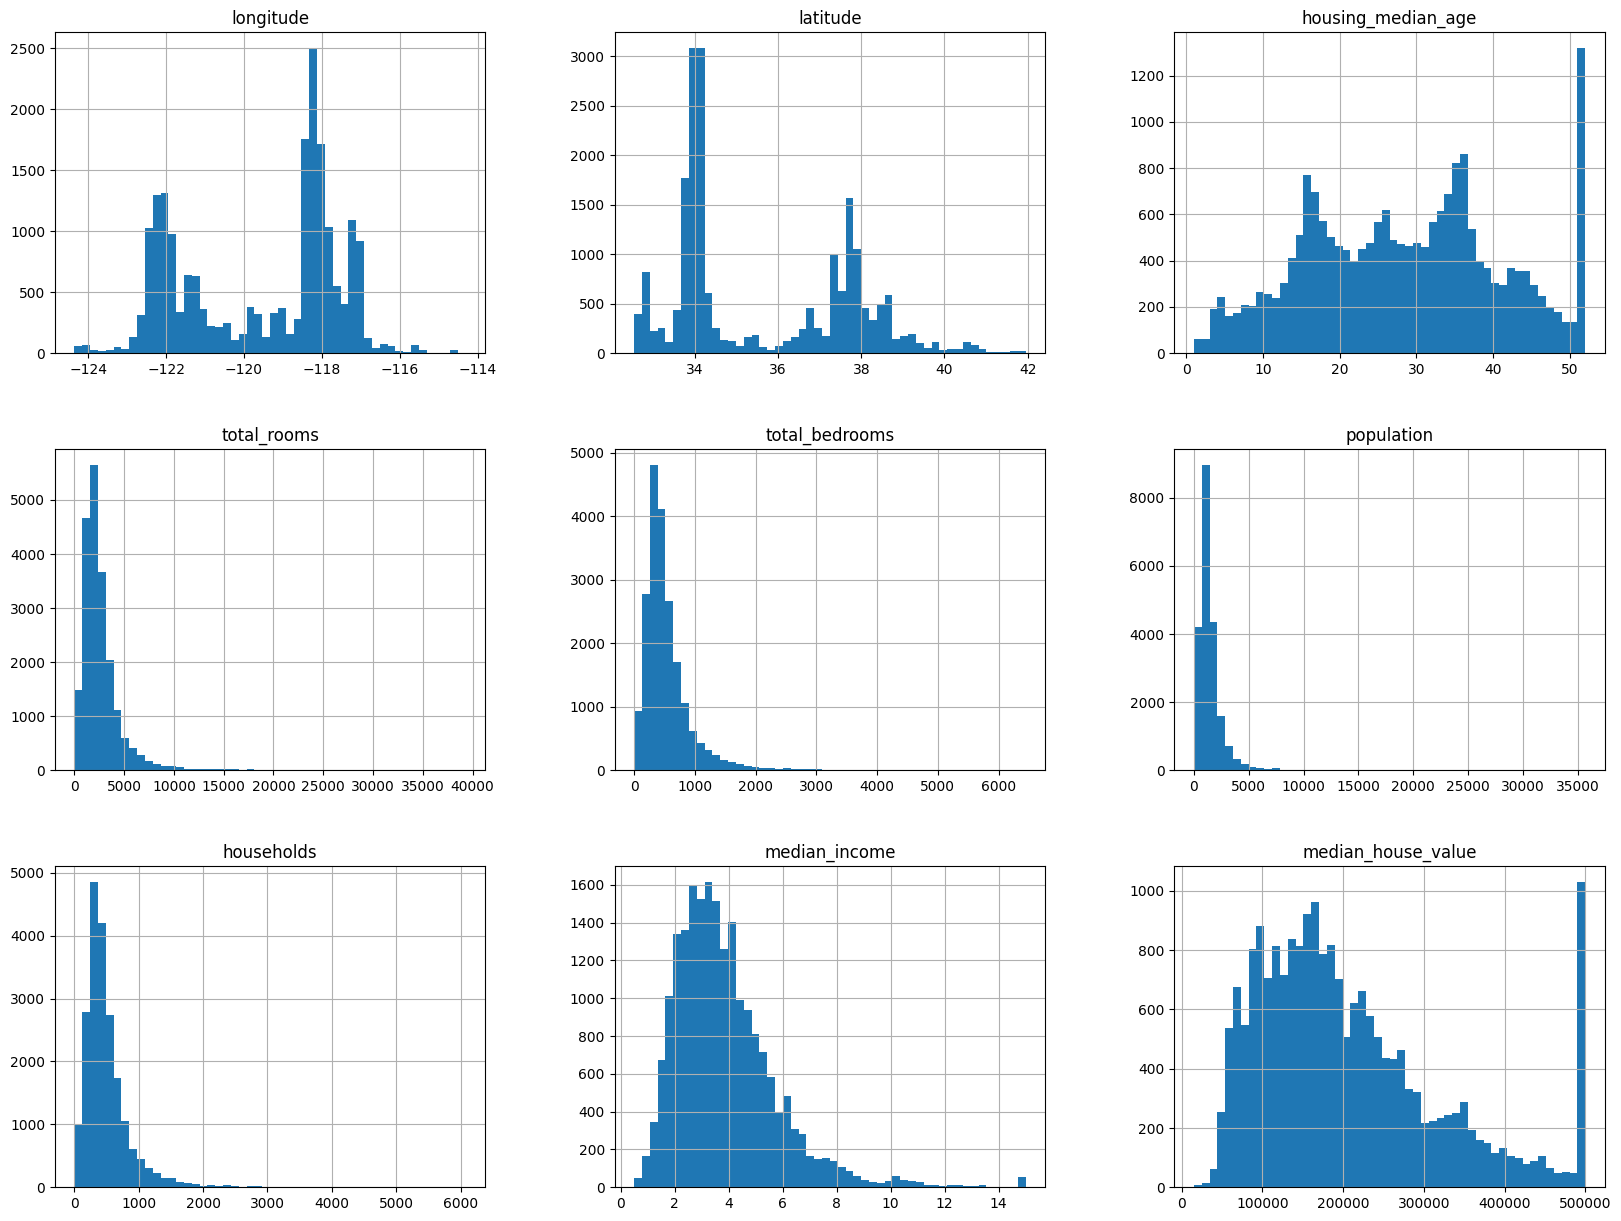

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
plt.show()

In [11]:
test_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,47700.0,INLAND
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,45800.0,INLAND
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,500001.0,NEAR BAY
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,218600.0,<1H OCEAN
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,278000.0,NEAR OCEAN


<Axes: >

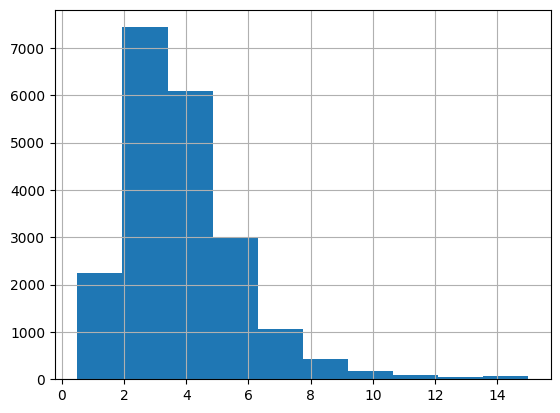

In [12]:
housing["median_income"].hist()

In [13]:
# Crea una nueva columna 'income_cat' categorizando 'median_income'
housing["income_cat"] = pd.cut(housing["median_income"],
# Define los límites de los bins para la categorización
bins= [0.,1.5,3.0,4.5,6., np.inf],
# Define las etiquetas para cada bin
labels= [1,2,3,4,5])

In [14]:
housing["income_cat"].value_counts()

,count
income_cat,
3,7236
2,6581
4,3639
5,2362
1,822


<Axes: >

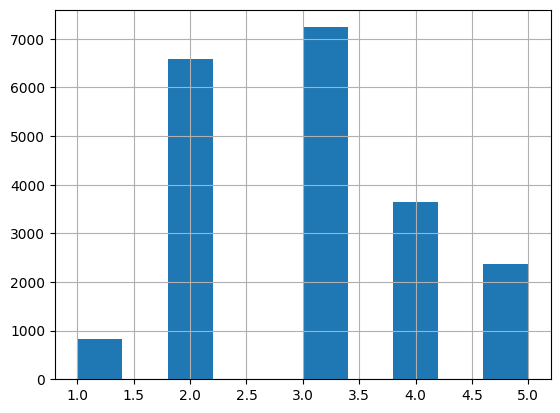

In [15]:
housing["income_cat"].hist()

In [16]:
from sklearn.model_selection import StratifiedShuffleSplit # Importa StratifiedShuffleSplit para división estratificada
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42) # Crea un objeto para realizar 1 división con 20% para prueba y estado aleatorio fijo
for train_index, test_index in split.split(housing, housing["income_cat"]): # Itera sobre las divisiones generadas
  strat_train_set = housing.loc[train_index] # Obtiene el conjunto de entrenamiento estratificado usando los índices
  strat_test_set = housing.loc[test_index] # Obtiene el conjunto de prueba estratificado usando los índices

In [17]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)
# Esto es útil para verificar que la división estratificada funcionó correctamente y que las proporciones
# de las categorías de ingresos en el conjunto de prueba son representativas de las proporciones en el conjunto de datos original.


,count
income_cat,
3,0.350533
2,0.318798
4,0.176357
5,0.114341
1,0.039971


In [18]:
housing["income_cat"].value_counts() / len(housing)

,count
income_cat,
3,0.350581
2,0.318847
4,0.176308
5,0.114438
1,0.039826


In [19]:
def income_cat_proportions(data):
  # Calcula y devuelve las proporciones de cada categoría en la columna "income_cat" del DataFrame dado
  return data["income_cat"].value_counts() / len(data)

# Divide el conjunto de datos original en entrenamiento y prueba de forma aleatoria (sin estratificación)
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

# Crea un DataFrame para comparar las proporciones de las categorías de ingresos
compare_props = pd.DataFrame({
"Overall": income_cat_proportions(housing), # Proporciones en el conjunto de datos completo
"Stratified": income_cat_proportions(strat_test_set), # Proporciones en el conjunto de prueba estratificado
"Random": income_cat_proportions(test_set), # Proporciones en el conjunto de prueba aleatorio
}).sort_index() # Ordena el DataFrame por el índice (las categorías de ingresos)

# Calcula el error porcentual de la división aleatoria en comparación con las proporciones generales
compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
# Calcula el error porcentual de la división estratificada en comparación con las proporciones generales
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100

In [20]:
compare_props

,Overall,Stratified,Random,Rand. %error,Strat. %error
income_cat,,,,,
1,0.039826,0.039971,0.040213,0.973236,0.364964
2,0.318847,0.318798,0.324370,1.732260,-0.015195
3,0.350581,0.350533,0.358527,2.266446,-0.013820
4,0.176308,0.176357,0.167393,-5.056334,0.027480
5,0.114438,0.114341,0.109496,-4.318374,-0.084674


In [21]:
for set_ in (strat_train_set, strat_test_set):
  set_.drop("income_cat", axis=1, inplace=True)

In [22]:
# 2. Explorar y visualizar los datos
housing = strat_train_set.copy() # hacer una copia

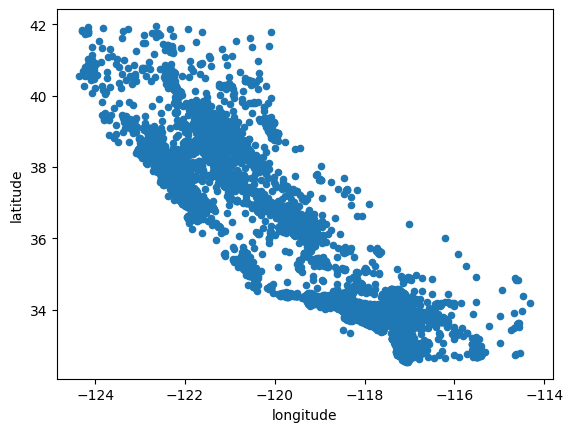

In [23]:
# scatterplot de los distritos
housing.plot(kind="scatter", x="longitude", y="latitude")
save_fig= ("bad_visualization_plot")

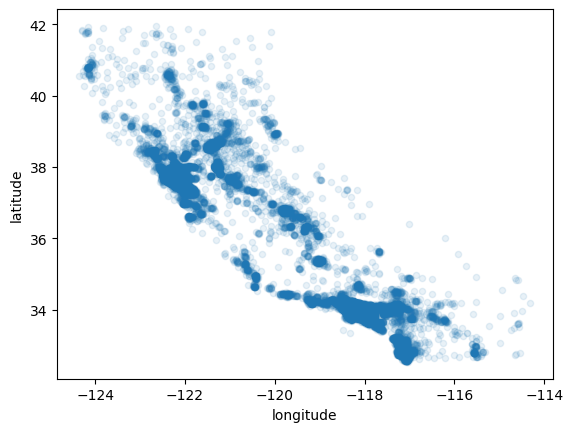

In [24]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)
save_fig= ("better_visualization_plot")

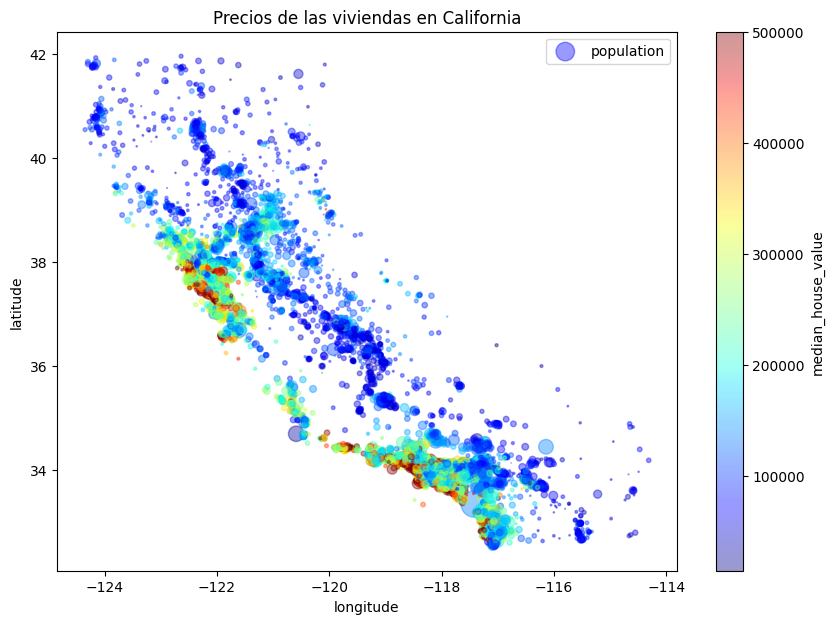

In [25]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
s=housing["population"]/100, label="population", figsize=(10,7),
c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
)
plt.legend()
plt.title("Precios de las viviendas en California") # Añade el título al gráfico
save_fig=("housing_prices_scatterplot")

In [26]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000000,16512.000000,16512.000000,16512.000000,16354.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.575635,35.639314,28.653404,2622.539789,534.914639,1419.687379,497.011810,3.875884,207005.322372
std,2.001828,2.137963,12.574819,2138.417080,412.665649,1115.663036,375.696156,1.904931,115701.297250
min,-124.350000,32.540000,1.000000,6.000000,2.000000,3.000000,2.000000,0.499900,14999.000000
25%,-121.800000,33.940000,18.000000,1443.000000,295.000000,784.000000,279.000000,2.566950,119800.000000
50%,-118.510000,34.260000,29.000000,2119.000000,433.000000,1164.000000,408.000000,3.541550,179500.000000
75%,-118.010000,37.720000,37.000000,3141.000000,644.000000,1719.000000,602.000000,4.745325,263900.000000
max,-114.310000,41.950000,52.000000,39320.000000,6210.000000,35682.000000,5358.000000,15.000100,500001.000000


In [27]:
sample_incomplete_rows= housing[housing.isnull().any(axis=1)].head()
sample_incomplete_rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
1606,-122.08,37.88,26.0,2947.0,NaN,825.0,626.0,2.9330,85000.0,NEAR BAY
10915,-117.87,33.73,45.0,2264.0,NaN,1970.0,499.0,3.4193,177000.0,<1H OCEAN
19150,-122.70,38.35,14.0,2313.0,NaN,954.0,397.0,3.7813,146500.0,<1H OCEAN
4186,-118.23,34.13,48.0,1308.0,NaN,835.0,294.0,4.2891,214800.0,<1H OCEAN
16885,-122.40,37.58,26.0,3281.0,NaN,1145.0,480.0,6.3580,500001.0,NEAR OCEAN


In [28]:
# 3. Preparar los datos
housing= strat_train_set.drop("median_house_value", axis=1)
housing_labels= strat_train_set["median_house_value"].copy()

In [29]:
from sklearn.impute import SimpleImputer # Importa SimpleImputer para manejar valores faltantes
imputer = SimpleImputer(strategy="median") # Crea un objeto SimpleImputer utilizando la estrategia de la mediana
housing_num = housing.drop("ocean_proximity", axis=1) # Crea un DataFrame con solo las columnas numéricas (elimina 'ocean_proximity')
imputer.fit(housing_num) # Ajusta el imputer a los datos numéricos para calcular la mediana de cada columna

SimpleImputer(strategy='median')

In [30]:
x= imputer.transform(housing_num) # Transforma los datos numéricos, rellenando los valores faltantes con las medianas calculadas
housing_tr= pd.DataFrame(x, columns=housing_num.columns, # Crea un nuevo DataFrame de pandas a partir del array transformado
index=housing.index) # Usa los índices originales del DataFrame 'housing'

In [31]:
print(housing_tr)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
12655    -121.46     38.52                29.0       3873.0           797.0   
15502    -117.23     33.09                 7.0       5320.0           855.0   
2908     -119.04     35.37                44.0       1618.0           310.0   
14053    -117.13     32.75                24.0       1877.0           519.0   
20496    -118.70     34.28                27.0       3536.0           646.0   
...          ...       ...                 ...          ...             ...   
15174    -117.07     33.03                14.0       6665.0          1231.0   
12661    -121.42     38.51                15.0       7901.0          1422.0   
19263    -122.72     38.44                48.0        707.0           166.0   
19140    -122.70     38.31                14.0       3155.0           580.0   
19773    -122.14     39.97                27.0       1079.0           222.0   

       population  households  median_income  
1265

In [32]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(10)

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
1481,NEAR BAY
18125,<1H OCEAN
5830,<1H OCEAN
17989,<1H OCEAN
4861,<1H OCEAN


In [33]:
from sklearn.preprocessing import OneHotEncoder # Importa OneHotEncoder para codificación one-hot de variables categóricas
cat_encoder = OneHotEncoder() # Crea una instancia de OneHotEncoder
housing_cat_1hot = cat_encoder.fit_transform(housing_cat) # Ajusta el codificador a los datos categóricos y los transforma a formato one-hot (salida dispersa)
housing_cat_1hot # Muestra la matriz dispersa resultante

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

OneHotEncoder es una herramienta que se utiliza para convertir variables categóricas (variables que toman valores de un conjunto limitado de categorías, como "cerca del océano", "interior", etc.) en un formato numérico que los algoritmos de Machine Learning puedan entender.

Muchos algoritmos de Machine Learning no pueden trabajar directamente con datos categóricos en su formato de texto. Si intentamos representarlos con números simples (por ejemplo, 0 para "interior", 1 para "cerca del océano"), el algoritmo podría interpretar que hay una relación de orden entre las categorías (que "cerca del océano" es "mayor" que "interior"), lo cual no es correcto.

OneHotEncoder resuelve esto creando nuevas columnas binarias (columnas que solo contienen 0s y 1s) por cada categoría única en la columna original. Por ejemplo, para la columna "ocean_proximity", crearía una columna para "INLAND", una para "NEAR OCEAN", etc. Si una fila tiene la categoría "INLAND", el valor en la columna "INLAND" será 1 y en las demás columnas de proximidad será 0.

De esta manera, el OneHotEncoder transforma la columna categórica en múltiples columnas numéricas donde cada columna representa una categoría de forma independiente, evitando que el algoritmo infiera relaciones de orden incorrectas y permitiéndole utilizar esta información categórica para el entrenamiento.

In [34]:
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [35]:
from sklearn.base import BaseEstimator, TransformerMixin # Importa las clases base para crear transformadores personalizados
# Define los índices de las columnas relevantes para la creación de atributos combinados
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
  # Inicializador de la clase, permite especificar si se añade el atributo 'bedrooms_per_room'
  def __init__(self, add_bedrooms_per_room = True): # no *args or **kargs
    self.add_bedrooms_per_room = add_bedrooms_per_room
  # Método fit, en este caso no hace nada ya que no hay parámetros que aprender de los datos
  def fit(self, X, y=None):
    return self # Retorna la instancia de la clase
  # Método transform, crea los nuevos atributos combinados
  def transform(self, X):
    # Calcula habitaciones por hogar
    rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
    # Calcula población por hogar
    population_per_household = X[:, population_ix] / X[:, households_ix]
    # Si se especifica, calcula dormitorios por habitación
    if self.add_bedrooms_per_room:
      bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
      # Devuelve la matriz original X concatenada con los nuevos atributos
      return np.c_[X, rooms_per_household, population_per_household,
      bedrooms_per_room]
    else:
      # Devuelve la matriz original X concatenada con los atributos sin 'bedrooms_per_room'
      return np.c_[X, rooms_per_household, population_per_household]

# Crea una instancia de la clase CombinedAttributesAdder sin añadir 'bedrooms_per_room'
attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
# Aplica la transformación a los datos de vivienda para obtener los atributos extra
housing_extra_attribs = attr_adder.transform(housing.values)

Esta clase, CombinedAttributesAdder, es un transformador personalizado que se crea para generar nuevos atributos combinando los atributos existentes en el conjunto de datos. En este caso específico, se utiliza para crear los siguientes atributos:

    rooms_per_household: El número promedio de habitaciones por hogar. Se calcula dividiendo el número total de habitaciones (total_rooms) por el número de hogares (households).
    population_per_household: El número promedio de personas por hogar. Se calcula dividiendo la población total (population) por el número de hogares (households).
    bedrooms_per_room (opcional): El número promedio de dormitorios por habitación. Se calcula dividiendo el número total de dormitorios (total_bedrooms) por el número total de habitaciones (total_rooms). Este atributo se puede incluir o excluir al crear una instancia de la clase.

La razón para crear estos atributos combinados es que a menudo pueden ser más informativos o tener una mejor relación con la variable objetivo (en este caso, el valor medio de la vivienda) que los atributos originales por separado. Al combinarlos, podemos capturar relaciones o ratios que podrían ser importantes para el modelo de Machine Learning.

Esta clase sigue el patrón de diseño de Scikit-learn para los transformadores (BaseEstimator y TransformerMixin), lo que permite que se integre fácilmente en pipelines de procesamiento de datos.

In [36]:
from sklearn.pipeline import Pipeline # Importa Pipeline para construir secuencias de transformaciones
from sklearn.preprocessing import StandardScaler # Importa StandardScaler para escalar características a la media 0 y varianza 1
from sklearn.impute import SimpleImputer # Asegúrate de importar SimpleImputer si no lo has hecho antes

# Define el pipeline para procesar las características numéricas
num_pipeline = Pipeline([
('imputer', SimpleImputer(strategy="median")), # Paso 1: Rellenar valores faltantes con la mediana
('attribs_adder', CombinedAttributesAdder()), # Paso 2: Añadir atributos combinados (habitaciones por hogar, etc.)
('std_scaler', StandardScaler()), # Paso 3: Escalar las características numéricas
])

# Aplica el pipeline a los datos numéricos de entrenamiento
housing_num_tr = num_pipeline.fit_transform(housing_num)

Ahora que hemos procesado las características numéricas con el pipeline, el siguiente paso es combinar estas características procesadas con las características categóricas (que ya codificamos con OneHotEncoder) en un único conjunto de datos. Este conjunto de datos combinado estará listo para ser utilizado en el entrenamiento de un modelo de Machine Learning.

In [37]:
from sklearn.compose import ColumnTransformer # Importa ColumnTransformer para aplicar diferentes transformaciones a diferentes columnas
num_attribs = list(housing_num) # Obtiene la lista de nombres de columnas numéricas
cat_attribs = ["ocean_proximity"] # Define la lista de nombres de columnas categóricas

# Crea un ColumnTransformer para aplicar transformaciones separadas a columnas numéricas y categóricas
full_pipeline = ColumnTransformer([
("num", num_pipeline, num_attribs), # Aplica el pipeline numérico a las columnas numéricas
("cat", OneHotEncoder(), cat_attribs), # Aplica OneHotEncoder a las columnas categóricas
])

# Aplica el pipeline completo a los datos de vivienda para preparar el conjunto de datos para el entrenamiento
housing_prepared = full_pipeline.fit_transform(housing)

Ahora que los datos están completamente preparados (housing_prepared), el siguiente paso es seleccionar y entrenar un modelo de Machine Learning para predecir los valores de las viviendas. Podemos empezar con un modelo simple como la Regresión Lineal.

In [38]:
# 4. Seleccionar el modelo y entrenarlo
from sklearn.linear_model import LinearRegression # Importa LinearRegression para entrenar un modelo de regresión lineal
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

LinearRegression()

In [39]:
sample_data = housing.iloc[:5] # Selecciona las primeras 5 filas del DataFrame 'housing' como datos de ejemplo
sample_labels = housing_labels.iloc[:5] # Selecciona las primeras 5 etiquetas correspondientes a los datos de ejemplo
sample_data_prepared = full_pipeline.transform(sample_data) # Prepara los datos de ejemplo usando el pipeline completo (imputación, atributos combinados, escalado y codificación one-hot)
print("Predictions:", lin_reg.predict(sample_data_prepared)) # Utiliza el modelo de regresión lineal entrenado para predecir los valores de las viviendas para los datos de ejemplo e imprime las predicciones
print("Labels:", list(sample_labels)) # Imprime las etiquetas reales de los datos de ejemplo

Predictions: [ 85657.90192014 305492.60737488 152056.46122456 186095.70946094
 244550.67966089]
Labels: [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


In [40]:
from sklearn.metrics import mean_squared_error
housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(68627.87390018745)

In [41]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

DecisionTreeRegressor()

In [42]:
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

np.float64(0.0)

In [43]:
from sklearn.model_selection import cross_val_score # Importa cross_val_score para realizar validación cruzada
scores = cross_val_score(tree_reg, housing_prepared, housing_labels,
scoring="neg_mean_squared_error", cv=10) # Realiza validación cruzada con 10 folds, usando el error cuadrático medio negativo como métrica
tree_rmse_scores = np.sqrt(-scores) # Calcula la raíz cuadrada de los scores (que son negativos) para obtener el RMSE

Ahora que hemos calculado los scores de validación cruzada para el modelo de Árbol de Decisión, el siguiente paso es mostrar estos scores y entender su distribución (media y desviación estándar) para evaluar el rendimiento del modelo.

In [44]:
def display_scores(scores):
  print("Scores:", scores)
  print("Mean:", scores.mean())
  print("Standard deviation:", scores.std())
display_scores(tree_rmse_scores)

Scores: [72184.03007244 70781.73704218 67815.85501967 70209.44901761
 69515.63911497 77587.98400967 69714.65559267 74177.20831302
 67261.92037614 72220.7317602 ]
Mean: 71146.92103185659
Standard deviation: 2912.258692318984


In [45]:
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels,
scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
Mean: 69104.07998247063
Standard deviation: 2880.3282098180694


In [46]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)

# Calculate the mean squared error on the training data
housing_predictions = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
print("RMSE on training data:", forest_rmse)

# Calculate and display the cross-validation scores
forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels,
scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

RMSE on training data: 18641.033663956467
Scores: [51132.717579   49177.27295566 46833.7031363  51941.2067351
 47462.84247801 51830.62767979 52520.97898108 49967.2822946
 48680.15096198 53614.35502479]
Mean: 50316.11378263042
Standard deviation: 2137.865858234156


In [51]:
# 5. Fine tune the model
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = [
    {'n_estimators': [3, 10,30], 'max_features': [2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
]
forest_reg = RandomForestRegressor()
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
scoring='neg_mean_squared_error',
return_train_score=True)
grid_search.fit(housing_prepared, housing_labels)

# 6. Evaluar el modelo

final_model = grid_search.best_estimator_
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()
X_test_prepared = full_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

En el código, se define una cuadrícula de hiperparámetros (param_grid) para RandomForestRegressor. Los parámetros seleccionados y sus valores son:

    n_estimators: Este parámetro define el número de árboles en el bosque aleatorio. Se prueban los valores [3, 10, 30]. Un mayor número de árboles generalmente mejora el rendimiento, pero también aumenta el tiempo de entrenamiento. La búsqueda evalúa estos valores para encontrar un equilibrio.
    max_features: Este parámetro controla el número de características a considerar cuando el modelo busca la mejor división en cada nodo de un árbol. Se prueban los valores [2, 4, 6, 8] en el primer conjunto de parámetros y [2, 3, 4] en el segundo. Limitar el número de características consideradas aleatoriamente en cada división ayuda a reducir la varianza del modelo.
    bootstrap: Este parámetro determina si se utilizan muestras bootstrap al construir los árboles. En el segundo conjunto de parámetros, se prueba [False], lo que significa que se utiliza todo el conjunto de datos para entrenar cada árbol en lugar de una muestra con reemplazo.

La razón para seleccionar estos parámetros y sus rangos específicos ([3, 10, 30], [2, 4, 6, 8], etc.) es encontrar la combinación óptima que le permita al modelo generalizar bien a datos no vistos. No hay una regla fija para elegir estos valores; a menudo se basan en la experiencia, recomendaciones comunes o pruebas preliminares. GridSearchCV automatiza el proceso de probar todas las combinaciones posibles dentro de la cuadrícula definida y selecciona la que produce el mejor rendimiento según la métrica de evaluación especificada (en este caso, el error cuadrático medio negativo).

En resumen, los parámetros y sus valores se eligen para explorar diferentes configuraciones del modelo Random Forest y GridSearchCV se encarga de encontrar la combinación que mejor se ajusta a tus datos de entrenamiento y validación cruzada.

In [48]:
# grid search best estimator
RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=None,
max_features=8, max_leaf_nodes=None, min_impurity_decrease=0.0,
min_samples_leaf=1, min_samples_split=2, min_weight_fraction_leaf=0.0,
n_estimators=30, n_jobs=None, oob_score=False, random_state=None,
verbose=0, warm_start=False)

RandomForestRegressor(criterion='mse', max_features=8, n_estimators=30)

In [52]:
from scipy import stats

# Define el nivel de confianza deseado para el intervalo
confidence = 0.95

# Calcula los errores cuadrados: la diferencia entre las predicciones finales y los valores reales, elevados al cuadrado
squared_errors = (final_predictions - y_test) ** 2

# Calcula el intervalo de confianza para la raíz cuadrada del error cuadrático medio (RMSE)
# stats.t.interval calcula el intervalo de confianza usando la distribución t de Student
# confidence: el nivel de confianza
# len(squared_errors) - 1: los grados de libertad
# loc=squared_errors.mean(): la media de los errores cuadrados (que es el MSE)
# scale=stats.sem(squared_errors): el error estándar de la media de los errores cuadrados
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                         loc=squared_errors.mean(),
                         scale=stats.sem(squared_errors)))

array([46134.66075303, 49993.85113284])

En este caso decidí como implementación propia usar Random Search para los 3 modelos (Regresion Lineal, Desicion Tree y Random Forest

En RandomizedSearchCV, en lugar de probar todas las combinaciones de hiperparámetros como lo hace GridSearchCV, se muestrean aleatoriamente un número fijo de combinaciones del espacio de búsqueda definido. Esto es especialmente útil cuando el espacio de hiperparámetros es grande, ya que puede reducir significativamente el tiempo de cálculo.

In [68]:
# Entrenar un modelo Decision Tree Regressor con Random Search
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np

# Define el espacio de hiperparámetros para RandomizedSearchCV
# max_depth: la profundidad máxima del árbol
# min_samples_split: el número mínimo de muestras requeridas para dividir un nodo interno
# min_samples_leaf: el número mínimo de muestras requeridas para estar en un nodo hoja
param_distribs = {
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

# Crea un modelo DecisionTreeRegressor
tree_reg = DecisionTreeRegressor(random_state=42)

# Configura RandomizedSearchCV
# estimator: el modelo a tunear
# param_distributions: el espacio de hiperparámetros a muestrear
# cv: número de folds para validación cruzada
# scoring: métrica para evaluar el modelo
# n_iter: número de iteraciones de muestreo
# random_state: semilla para reproducibilidad
random_search = RandomizedSearchCV(tree_reg, param_distribs, cv=5,
                                   scoring='neg_mean_squared_error',
                                   n_iter=10, random_state=42)

# Ejecuta la búsqueda aleatoria en los datos de entrenamiento preparados
random_search.fit(housing_prepared, housing_labels)

# Obtén el mejor modelo encontrado por RandomizedSearchCV
best_tree_reg = random_search.best_estimator_

# Evaluar el modelo en el conjunto de entrenamiento
housing_predictions_train = best_tree_reg.predict(housing_prepared)
tree_mse_train = mean_squared_error(housing_labels, housing_predictions_train)
tree_rmse_train = np.sqrt(tree_mse_train)
print("RMSE en el conjunto de entrenamiento (después de Random Search):", tree_rmse_train)

# Evaluar el modelo en el conjunto de prueba
# Preparar los datos de prueba (ya se hizo en celdas anteriores, solo se usan las variables existentes)
# X_test_prepared = full_pipeline.transform(X_test)
# y_test (ya existe)

final_predictions_test = best_tree_reg.predict(X_test_prepared)
tree_mse_test = mean_squared_error(y_test, final_predictions_test)
tree_rmse_test = np.sqrt(tree_mse_test)
print("RMSE en el conjunto de prueba (después de Random Search):", tree_rmse_test)

RMSE en el conjunto de entrenamiento (después de Random Search): 48288.166070354746
RMSE en el conjunto de prueba (después de Random Search): 58772.103556837006


Los parámetros seleccionados para el DecisionTreeRegressor en param_distribs son:

    max_depth: Este parámetro controla la profundidad máxima del árbol de decisión. Limitar la profundidad puede ayudar a prevenir el sobreajuste (overfitting). Se incluyen valores como None (sin límite de profundidad), 10, 20, 30, 40 y 50 para explorar diferentes niveles de complejidad del modelo.
    min_samples_split: Este parámetro define el número mínimo de muestras requeridas para dividir un nodo interno. Un valor más alto puede evitar que el modelo aprenda divisiones muy específicas de los datos de entrenamiento. Se prueban valores como 2, 5 y 10.
    min_samples_leaf: Este parámetro define el número mínimo de muestras requeridas para estar en un nodo hoja. Al igual que min_samples_split, un valor más alto puede suavizar el modelo y reducir el sobreajuste. Se prueban valores como 1, 2 y 4.

La selección de estos rangos de valores ([None, 10, 20, 30, 40, 50], [2, 5, 10], [1, 2, 4]) se basa en probar diferentes configuraciones que son comunes para los árboles de decisión y que cubren un rango razonable de complejidad del modelo. RandomizedSearchCV probará 10 combinaciones aleatorias de estos parámetros (definido por n_iter=10) y seleccionará la que resulte en el menor error cuadrático medio negativo (mayor score) durante la validación cruzada (cv=5).

El objetivo de RandomizedSearchCV es encontrar una combinación de hiperparámetros que permita al modelo DecisionTreeRegressor tener un buen rendimiento tanto en los datos de entrenamiento como en los datos no vistos (conjunto de prueba).

In [69]:
# Entrenar un modelo Linear Regression con Random Search
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np

# Define un espacio de hiperparámetros para RandomizedSearchCV.
# Para LinearRegression, no hay hiperparámetros típicos para tunear con Random Search
# de la misma manera que con modelos de árbol. Sin embargo, para cumplir con la solicitud,
# definiremos una cuadrícula de parámetros vacía o con un solo valor si es necesario.
# Si hubiera hiperparámetros (como en otras variantes de regresión lineal regularizada),
# se listarían aquí. Para la LinearRegression básica, la búsqueda no tendrá efecto.
param_distribs = {} # No hay hiperparámetros para tunear en LinearRegression básica

# Crea un modelo LinearRegression
lin_reg = LinearRegression()

# Configura RandomizedSearchCV
# estimator: el modelo a tunear
# param_distributions: el espacio de hiperparámetros a muestrear (vacío en este caso)
# cv: número de folds para validación cruzada
# scoring: métrica para evaluar el modelo
# n_iter: número de iteraciones de muestreo (1 en este caso, ya que no hay parámetros que variar)
# random_state: semilla para reproducibilidad (opcional, pero buena práctica)
random_search_lr = RandomizedSearchCV(lin_reg, param_distribs, cv=5,
                                   scoring='neg_mean_squared_error',
                                   n_iter=1, random_state=42) # n_iter=1 ya que solo hay una "combinación" de parámetros

# Ejecuta la búsqueda aleatoria (que en este caso es solo una ejecución del modelo con validación cruzada)
random_search_lr.fit(housing_prepared, housing_labels)

# Obtén el mejor modelo encontrado por RandomizedSearchCV (será el modelo LinearRegression ajustado)
best_lin_reg = random_search_lr.best_estimator_

# Evaluar el modelo en el conjunto de entrenamiento
housing_predictions_train_lr = best_lin_reg.predict(housing_prepared)
lin_mse_train = mean_squared_error(housing_labels, housing_predictions_train_lr)
lin_rmse_train = np.sqrt(lin_mse_train)
print("RMSE en el conjunto de entrenamiento (Linear Regression con Random Search):", lin_rmse_train)

# Evaluar el modelo en el conjunto de prueba
# X_test_prepared y y_test ya existen de celdas anteriores

final_predictions_test_lr = best_lin_reg.predict(X_test_prepared)
lin_mse_test = mean_squared_error(y_test, final_predictions_test_lr)
lin_rmse_test = np.sqrt(lin_mse_test)
print("RMSE en el conjunto de prueba (Linear Regression con Random Search):", lin_rmse_test)

RMSE en el conjunto de entrenamiento (Linear Regression con Random Search): 68627.87390018745
RMSE en el conjunto de prueba (Linear Regression con Random Search): 66913.4419132093


Es importante notar que, para un modelo de LinearRegression estándar, no hay hiperparámetros que se ajusten típicamente mediante técnicas de búsqueda como RandomizedSearchCV o GridSearchCV. La regresión lineal simple no tiene los mismos tipos de parámetros de ajuste que modelos más complejos como los árboles de decisión o los bosques aleatorios (por ejemplo, max_depth, min_samples_split, n_estimators, etc.).

En este caso, como el diccionario param_distribs está vacío ({}), RandomizedSearchCV esencialmente ejecuta el modelo LinearRegression una sola vez con su configuración predeterminada y realiza validación cruzada para evaluar su rendimiento. No hay una "búsqueda" real de hiperparámetros porque no hay ninguno definido para buscar.

La selección de parámetros, por lo tanto, se limita a los parámetros predeterminados de LinearRegression (como si fit se hubiera llamado directamente), y RandomizedSearchCV simplemente proporciona una forma de evaluar el modelo utilizando validación cruzada con la métrica especificada (neg_mean_squared_error).

Se obtuvo el RMSE en el conjunto de entrenamiento y en el conjunto de prueba para evaluar el rendimiento del modelo de Regresión Lineal.

In [70]:
# Entrenar un modelo Random Forest Regressor con Random Search
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np

# Define el espacio de hiperparámetros para RandomizedSearchCV
# n_estimators: número de árboles en el bosque
# max_features: número de características a considerar en cada división
# max_depth: profundidad máxima del árbol
# min_samples_split: número mínimo de muestras para dividir un nodo
# min_samples_leaf: número mínimo de muestras en un nodo hoja
param_distribs_rf = {
    'n_estimators': [3, 10, 30, 100, 300],
    'max_features': [2, 4, 6, 8, 10, 12],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

# Crea un modelo RandomForestRegressor
forest_reg_rs = RandomForestRegressor(random_state=42)

# Configura RandomizedSearchCV
# estimator: el modelo a tunear
# param_distributions: el espacio de hiperparámetros a muestrear
# cv: número de folds para validación cruzada
# scoring: métrica para evaluar el modelo
# n_iter: número de iteraciones de muestreo (puedes ajustar este valor)
# random_state: semilla para reproducibilidad
random_search_rf = RandomizedSearchCV(forest_reg_rs, param_distribs_rf, cv=5,
                                   scoring='neg_mean_squared_error',
                                   n_iter=20, random_state=42) # Aumenté n_iter para una búsqueda más amplia

# Ejecuta la búsqueda aleatoria en los datos de entrenamiento preparados
random_search_rf.fit(housing_prepared, housing_labels)

# Obtén el mejor modelo encontrado por RandomizedSearchCV
best_forest_reg_rs = random_search_rf.best_estimator_

# Evaluar el modelo en el conjunto de entrenamiento
housing_predictions_train_rf = best_forest_reg_rs.predict(housing_prepared)
forest_mse_train_rs = mean_squared_error(housing_labels, housing_predictions_train_rf)
forest_rmse_train_rs = np.sqrt(forest_mse_train_rs)
print("RMSE en el conjunto de entrenamiento (Random Forest con Random Search):", forest_rmse_train_rs)

# Evaluar el modelo en el conjunto de prueba
# X_test_prepared y y_test ya existen de celdas anteriores

final_predictions_test_rf = best_forest_reg_rs.predict(X_test_prepared)
forest_mse_test_rs = mean_squared_error(y_test, final_predictions_test_rf)
forest_rmse_test_rs = np.sqrt(forest_mse_test_rs)
print("RMSE en el conjunto de prueba (Random Forest con Random Search):", forest_rmse_test_rs)

RMSE en el conjunto de entrenamiento (Random Forest con Random Search): 18948.633307765213
RMSE en el conjunto de prueba (Random Forest con Random Search): 46869.40410277555



    n_estimators: Define el número de árboles en el bosque. Los valores [3, 10, 30, 100, 300] exploran diferentes tamaños de bosque. Generalmente, más árboles mejoran el rendimiento pero aumentan el tiempo de cálculo.
    max_features: Controla el número de características consideradas aleatoriamente en cada división del nodo. Los valores [2, 4, 6, 8, 10, 12] permiten explorar cómo limitar el número de características afecta al modelo. Limitar max_features ayuda a reducir la varianza.
    max_depth: La profundidad máxima de cada árbol en el bosque. [None, 10, 20, 30] explora desde árboles sin límite de profundidad hasta árboles más restringidos, ayudando a controlar el sobreajuste.
    min_samples_split: El número mínimo de muestras requeridas para dividir un nodo interno. Los valores [2, 5, 10] exploran cómo la exigencia para dividir un nodo afecta al modelo, ayudando a prevenir sobreajuste en datos de entrenamiento.
    min_samples_leaf: El número mínimo de muestras requeridas para estar en un nodo hoja. Los valores [1, 2, 4] exploran diferentes tamaños mínimos para los nodos hoja, también para ayudar a controlar el sobreajuste.

La selección de estos rangos se basa en la práctica común y en la exploración de un espacio razonable de configuraciones para un modelo de Random Forest. RandomizedSearchCV muestrea 20 combinaciones aleatorias de estos parámetros (n_iter=20) y selecciona la que produce el mejor score (menor error cuadrático medio negativo) durante la validación cruzada (cv=5). El objetivo es encontrar una combinación de hiperparámetros que logre un buen equilibrio entre el ajuste a los datos de entrenamiento y la capacidad de generalización a datos nuevos.

In [71]:
import pandas as pd

# Crear un DataFrame para comparar los resultados de los modelos en el conjunto de prueba
# Asegúrate de que las variables lin_rmse_test, tree_rmse_test y forest_rmse_test_rs existan de celdas anteriores
comparison_data = {'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
                   'Test RMSE': [lin_rmse_test, tree_rmse_test, forest_rmse_test_rs]}
comparison_df = pd.DataFrame(comparison_data)

# Ordenar por Test RMSE para encontrar el mejor modelo (menor RMSE es mejor)
comparison_df = comparison_df.sort_values(by='Test RMSE')

print("Comparación de modelos (RMSE en el conjunto de prueba):")
display(comparison_df)

# Identificar el mejor modelo
best_model_name = comparison_df.iloc[0]['Model']
best_rmse = comparison_df.iloc[0]['Test RMSE']

print(f"\nEl mejor modelo basado en el Test RMSE es: {best_model_name} con un RMSE de {best_rmse:.2f}")

Comparación de modelos (RMSE en el conjunto de prueba):


,Model,Test RMSE
2,Random Forest,46869.404103
1,Decision Tree,58772.103557
0,Linear Regression,66913.441913



El mejor modelo basado en el Test RMSE es: Random Forest con un RMSE de 46869.40


Para implementar localmente el mejor modelo (Random Forest) con Streamlit, primero necesitamos guardar el modelo entrenado y el pipeline de preprocesamiento. Luego crearemos un script de Python para la aplicación Streamlit.

In [72]:
import joblib
import os

# Define the directory to save the model and pipeline
model_dir = "saved_models"
os.makedirs(model_dir, exist_ok=True)

# Save the best Random Forest model
joblib.dump(best_forest_reg_rs, os.path.join(model_dir, "best_random_forest_model.pkl"))

# Save the full pipeline (including preprocessing)
joblib.dump(full_pipeline, os.path.join(model_dir, "full_pipeline.pkl"))

print(f"Modelo y pipeline guardados en el directorio: {model_dir}")

Modelo y pipeline guardados en el directorio: saved_models


In [74]:
import shutil
import os
from google.colab import files

# Define the directory to be zipped
model_dir = "saved_models"
# Define the name for the zip file
zip_filename = "saved_models.zip"

# Create a zip archive of the directory
shutil.make_archive(model_dir, 'zip', model_dir)

# Download the zip file
files.download(zip_filename)

print(f"Carpeta '{model_dir}' comprimida en '{zip_filename}' y lista para descargar.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Carpeta 'saved_models' comprimida en 'saved_models.zip' y lista para descargar.
